# Presentation code

In [1]:
import os, re, json, math, warnings, copy
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (classification_report, confusion_matrix, f1_score, accuracy_score,
                             precision_recall_fscore_support)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.svm import LinearSVC, SVC
from sklearn.neural_network import MLPClassifier
from sklearn.inspection import permutation_importance
import warnings
from sklearn.exceptions import ConvergenceWarning
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from sklearn.utils.class_weight import compute_class_weight
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [2]:
## PCAWG data is performed by the same pipeline
PCAWG_wgs_mut = pd.read_csv ("./project_data/catalogs/WGS/WGS_PCAWG.96.csv")
PCAWG_wgs_mut.head(2)

,Mutation type,Trinucleotide,Biliary-AdenoCA::SP117655,Biliary-AdenoCA::SP117556,Biliary-AdenoCA::SP117627,Biliary-AdenoCA::SP117775,Biliary-AdenoCA::SP117332,Biliary-AdenoCA::SP117712,Biliary-AdenoCA::SP117017,Biliary-AdenoCA::SP117031,...,Uterus-AdenoCA::SP94540,Uterus-AdenoCA::SP95222,Uterus-AdenoCA::SP89389,Uterus-AdenoCA::SP90503,Uterus-AdenoCA::SP92460,Uterus-AdenoCA::SP92931,Uterus-AdenoCA::SP91265,Uterus-AdenoCA::SP89909,Uterus-AdenoCA::SP90629,Uterus-AdenoCA::SP95550
0,C>A,ACA,269,114,105,217,52,192,54,196,...,117,233,94,114,257,139,404,97,250,170
1,C>A,ACC,148,56,71,123,36,139,54,102,...,90,167,59,64,268,75,255,78,188,137


In [3]:
## Activities:
PCAWG_wgs_act = pd.read_csv ("./project_data/activities/WGS/WGS_PCAWG.activities.csv")
PCAWG_wgs_act.head(2)

,Cancer Types,Sample Names,Accuracy,SBS1,SBS2,SBS3,SBS4,SBS5,SBS6,SBS7a,...,SBS51,SBS52,SBS53,SBS54,SBS55,SBS56,SBS57,SBS58,SBS59,SBS60
0,Biliary-AdenoCA,SP117655,0.968,1496,1296,0,0,1825,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Biliary-AdenoCA,SP117556,0.963,985,0,0,0,922,0,0,...,0,0,0,0,0,0,0,0,0,0


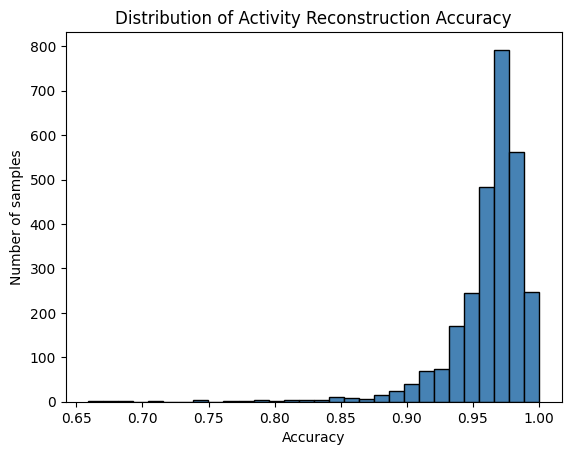

In [4]:
plt.hist(PCAWG_wgs_act['Accuracy'], bins=30, color='steelblue', edgecolor='black')
plt.xlabel('Accuracy')
plt.ylabel('Number of samples')
plt.title('Distribution of Activity Reconstruction Accuracy')
plt.show()

In [5]:
list_muts = [PCAWG_wgs_mut]
list_acts = [PCAWG_wgs_act]

## Preprocessing

Using the all of the data (WGS and WES) multiple different models were used in the preliminary testing of models. The final used data is a combination of $96$ catalogs and $65$ SBS signature activities. Labels with less than $30$ samples were excluded. 

Additionally, row normalization was used so that each sample sums to $1$, converts counts to compositional proportions and removes the mutation burden magnitude for activities and the mutational signatures were log-transformed to keep mutational burden differences and variance, i.e., keeping the biological significance. 

A mutation channel index was constructed based on 'Mutation type' and 'Trinucleotide' columns and then concatenated, so that rows become samples and columns mutational channels after transform. Cancer types were used as labels. 

Using the "Accuracy" column values, reconstructed profiles from Single Base Substitution (SBS) activites under the $n < 0.90$, where $n$ is the accuracy value, threshold was filtered out. 

In [6]:
# -------------------------------
# PROFILE & ACTIVITY PROCESSING
# -------------------------------

def process_profile_data(mut_dfs, normalize=False, log_transform=False):
    """
    Transpose mutation catalogs so samples are rows and optionally normalize / log-transform.
    """
    base_df = mut_dfs[0].copy()
    channel_index = base_df['Mutation type'] + "_" + base_df['Trinucleotide']
    combined_df = pd.DataFrame(index=channel_index)

    for df in mut_dfs:
        temp = df.drop(['Mutation type', 'Trinucleotide'], axis=1)
        temp.index = channel_index
        combined_df = pd.concat([combined_df, temp], axis=1)

    X = combined_df.T
    y = X.index.map(lambda x: x.split("::")[0])

    if normalize:
        X = X.div(X.sum(axis=1), axis=0)
    if log_transform:
        X = np.log1p(X)

    return X, y

def process_activity_data(act_dfs, normalize=False):
    """
    Concatenate activity dataframes and optionally normalize rows to sum=1.
    """
    accuracy_threshold = 0.90
    combined_act = pd.DataFrame()
    for df in act_dfs:
        temp = df.copy()
        
        # --- Filter by Accuracy first ---
        if 'Accuracy' in temp.columns:
            temp = temp[temp['Accuracy'] >= accuracy_threshold]

        # --- Construct index and drop metadata columns ---
        temp['index_id'] = temp['Cancer Types'] + "::" + temp['Sample Names']
        temp = temp.set_index('index_id')
        cols_to_drop = ['Cancer Types', 'Sample Names', 'Accuracy']
        temp = temp.drop([c for c in cols_to_drop if c in temp.columns], axis=1)
        combined_act = pd.concat([combined_act, temp], axis=0)

    combined_act = combined_act.fillna(0)
    if normalize:
        combined_act = combined_act.div(combined_act.sum(axis=1), axis=0)

    return combined_act


In [7]:

# -------------------------------
# FILTER RARE CLASSES
# -------------------------------
def filter_classes(X_train, y_train, X_test, y_test, min_samples=30):
    counts = y_train.value_counts()
    keep = counts[counts >= min_samples].index
    X_train_f = X_train[y_train.isin(keep)]
    y_train_f = y_train[y_train.isin(keep)]
    X_test_f = X_test[y_test.isin(keep)]
    y_test_f = y_test[y_test.isin(keep)]
    return X_train_f, y_train_f, X_test_f, y_test_f


In [8]:

# -------------------------------
# UNIFIED DATA PREPARATION
# -------------------------------
def prepare_data(mut_dfs, act_dfs,
                 normalize_profiles=False, log_profiles=True,
                 normalize_activities=True,
                 min_samples=30,
                 test_size=0.2, random_state=42):
    
    X_profiles, y_labels = process_profile_data(mut_dfs, normalize=normalize_profiles, log_transform=log_profiles)
    X_activities = process_activity_data(act_dfs, normalize=normalize_activities)

    # Keep only samples common to both
    common_idx = X_profiles.index.intersection(X_activities.index)
    X_prof_common = X_profiles.loc[common_idx]
    X_act_common = X_activities.loc[common_idx]
    y_common = y_labels[X_profiles.index.isin(common_idx)]

    X_combined = pd.concat([X_prof_common, X_act_common], axis=1)
    print(f"Total Samples Processed: {len(y_common)}")
    print(f"Profile Features: {X_prof_common.shape[1]}")
    print(f"Activity Features: {X_act_common.shape[1]}")

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_combined, y_common,
        test_size=test_size,
        stratify=y_common,
        random_state=random_state
    )

    # Filter rare classes
    X_train_f, y_train_f, X_test_f, y_test_f = filter_classes(X_train, y_train, X_test, y_test, min_samples)

    return X_train_f, y_train_f, X_test_f, y_test_f


In [9]:

# -------------------------------
# STANDARDIZE FEATURES FOR LR / SVM / MLP
# -------------------------------
def standardize_data(X_train, X_test):
    scaler = StandardScaler()
    X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), index=X_train.index, columns=X_train.columns)
    X_test_scaled = pd.DataFrame(scaler.transform(X_test), index=X_test.index, columns=X_test.columns)
    return X_train_scaled, X_test_scaled


## Models (Logistic Regression, Random Forest, SVM, MLP)

Models used were Logistic Regression (LR), Random Forest (RF), Support Vector Machine (SVM) and a Multilayer Perceptron (MLP). All used random state of $42$. Iteration used for LR was $20000$. RF used $200$ estimators. SVM had kernel function "rbf" and C set to $1$. 

In [10]:
# -------------------------------
# TEST EVALUATION
# -------------------------------
def evaluate_test(model, X_test, y_test, model_name="Model"):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average="macro")
    f1_weighted = f1_score(y_test, y_pred, average="weighted")

    print(f"\n===== {model_name} TEST =====")
    print(f"Accuracy:    {acc:.4f}")
    print(f"Macro F1:    {f1_macro:.4f}")
    print(f"Weighted F1: {f1_weighted:.4f}")

    # Confusion matrix
    labels = sorted(y_test.unique())
    cm = confusion_matrix(y_test, y_pred, labels=labels)
    plt.figure(figsize=(12,10))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
    plt.title(f"{model_name} Test Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    return acc, f1_macro, f1_weighted

In [11]:
# 1. Prepare data
X_train_f, y_train_f, X_test_f, y_test_f = prepare_data(
    list_muts, list_acts,
    normalize_profiles=False,   # don't collapse variance for LR
    log_profiles=True,          # log-transform helps
    normalize_activities=True,
    min_samples=30
)


Total Samples Processed: 2678
Profile Features: 96
Activity Features: 65



===== Logistic Regression TEST =====
Accuracy:    0.7960
Macro F1:    0.7678
Weighted F1: 0.7946


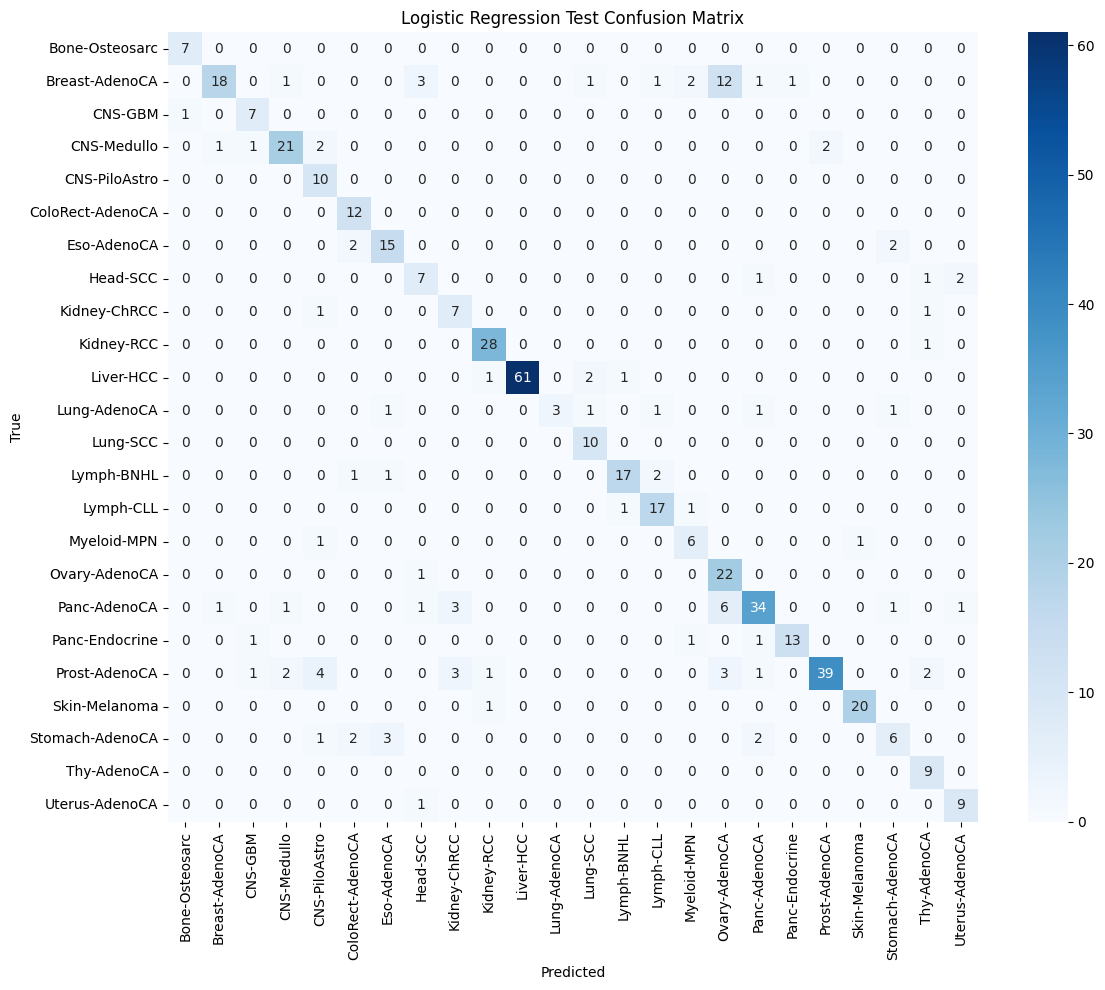


===== Random Forest TEST =====
Accuracy:    0.7460
Macro F1:    0.6635
Weighted F1: 0.7320


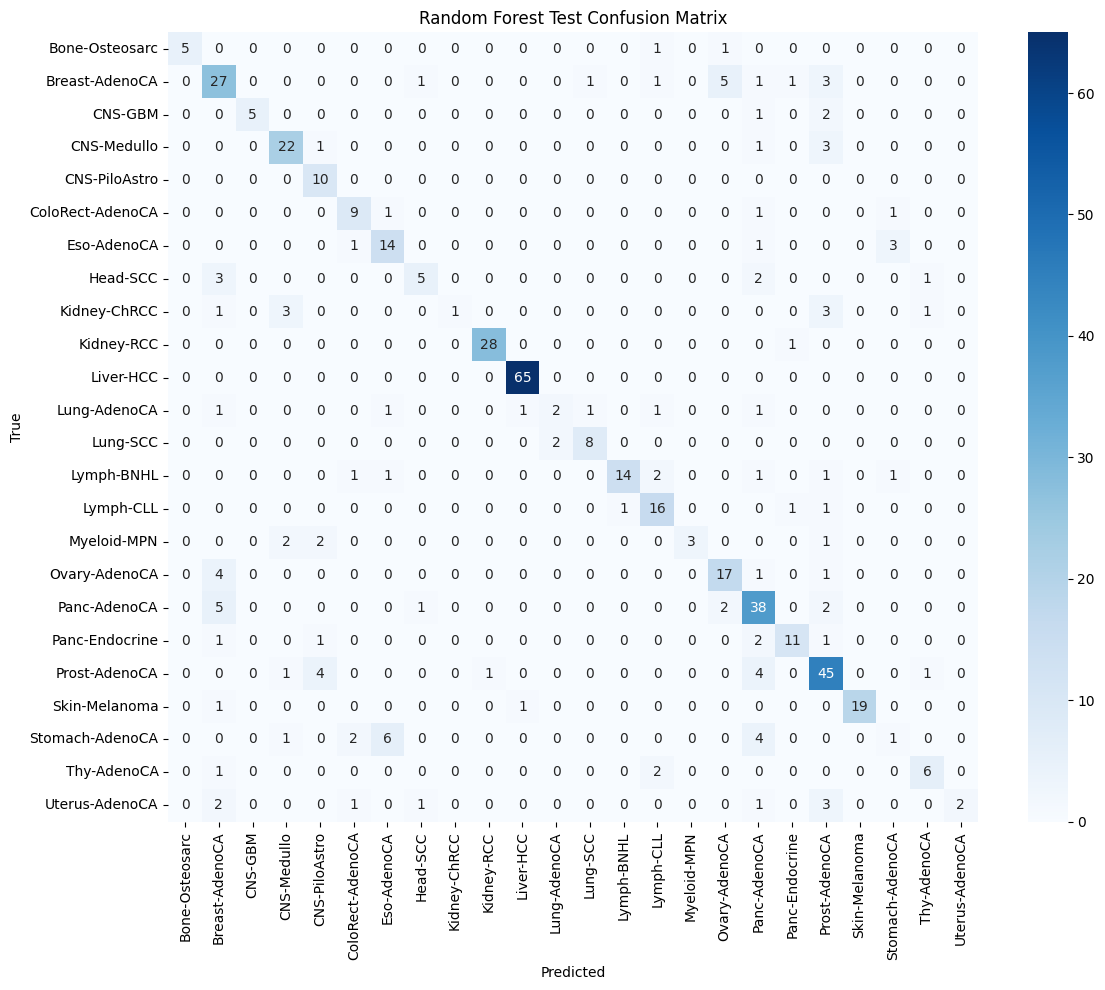


===== SVM TEST =====
Accuracy:    0.7960
Macro F1:    0.7436
Weighted F1: 0.7892


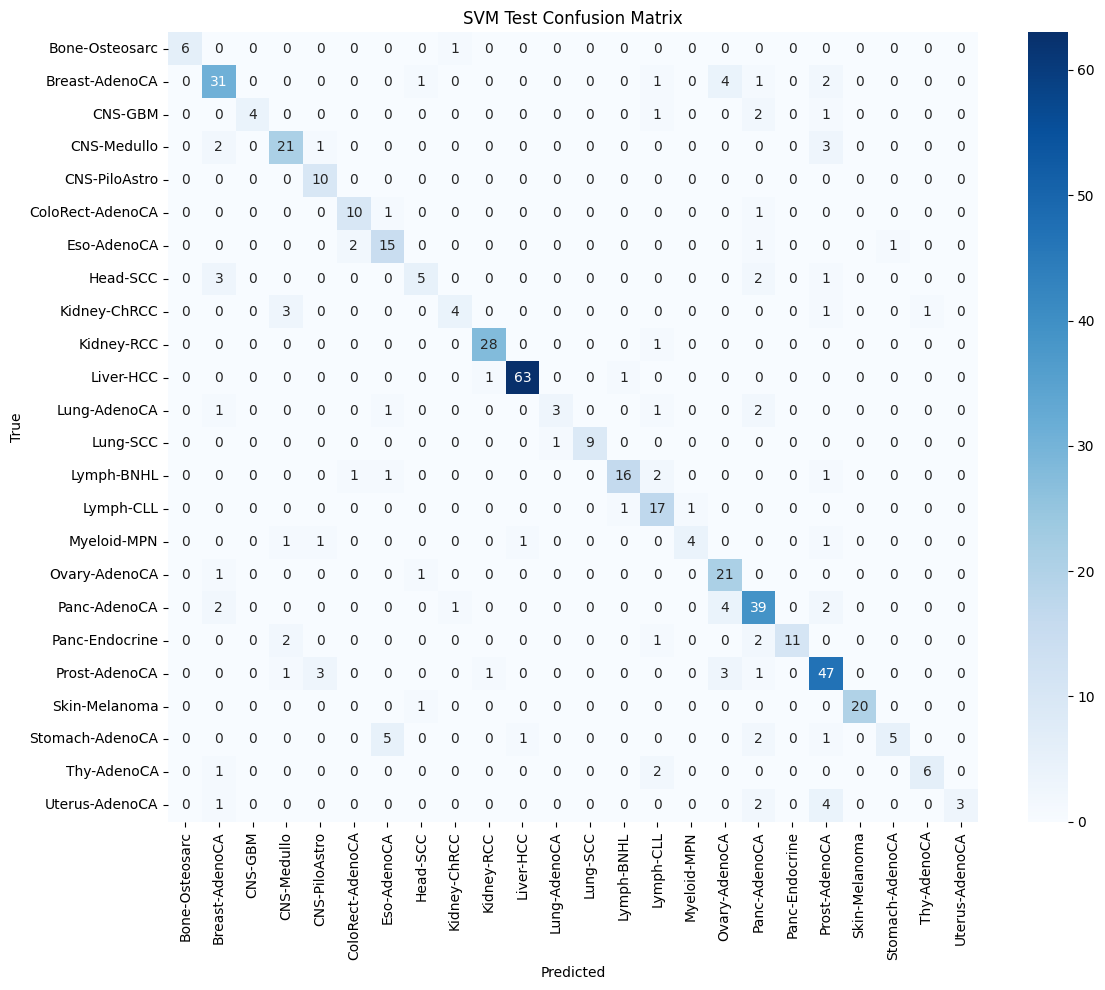


===== MLP TEST =====
Accuracy:    0.8800
Macro F1:    0.8561
Weighted F1: 0.8821


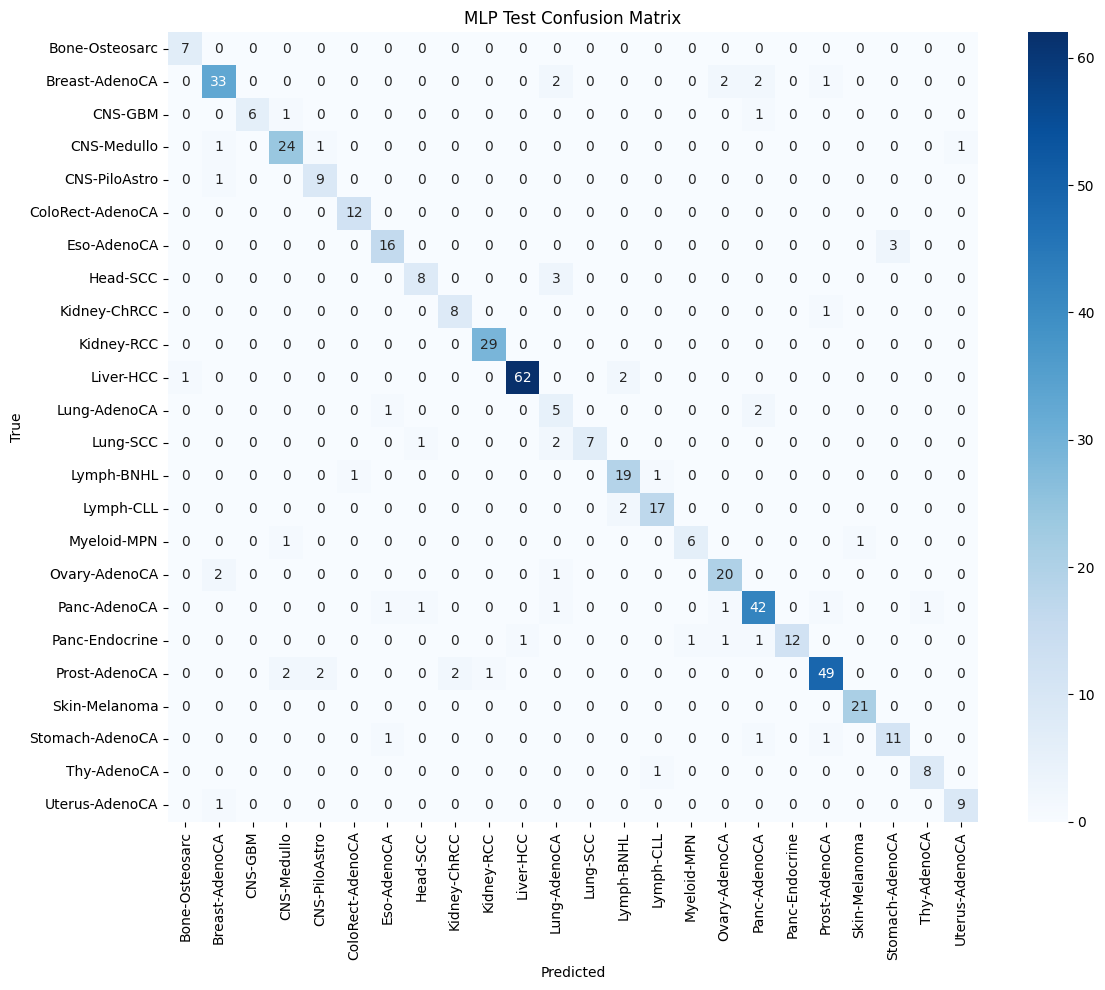

In [12]:


# 2. Define models
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("lr", LogisticRegression(max_iter=20000, class_weight='balanced', C=0.01, random_state=42))
    ]),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=200, random_state=42, n_jobs=-1
    ),
    
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="rbf", C=1.0, random_state=42))
    ]),
    
    "MLP": Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPClassifier(hidden_layer_sizes=(100,50), max_iter=1000, random_state=42))
    ])
}

# 3. Run Test Evaluation
results_dict = {}

for name, model in models.items():
    model.fit(X_train_f, y_train_f) 
    test_metrics = evaluate_test(model, X_test_f, y_test_f, model_name=name)
    results_dict[name] = {"test": test_metrics}

### Neural Network

Device: cpu
  5-Fold Cross-Validation on Dev Set
  Fold 1: Val Accuracy = 0.8800
  Fold 2: Val Accuracy = 0.8450
  Fold 3: Val Accuracy = 0.8425
  Fold 4: Val Accuracy = 0.8475
  Fold 5: Val Accuracy = 0.8600

  CV Mean ± Std: 0.8550 ± 0.0139

Ensemble Test Accuracy: 0.8760 (87.60%)


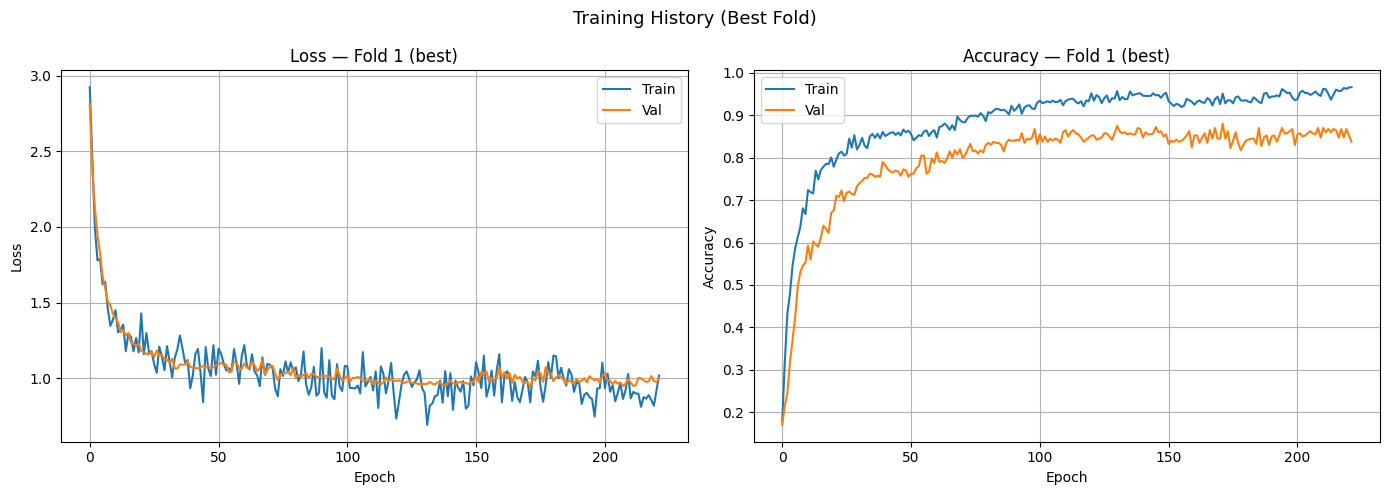

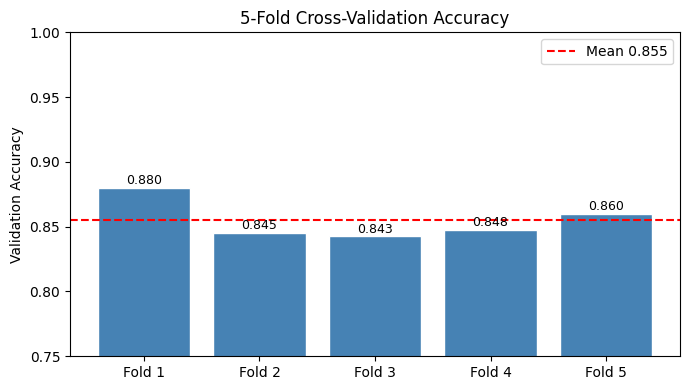

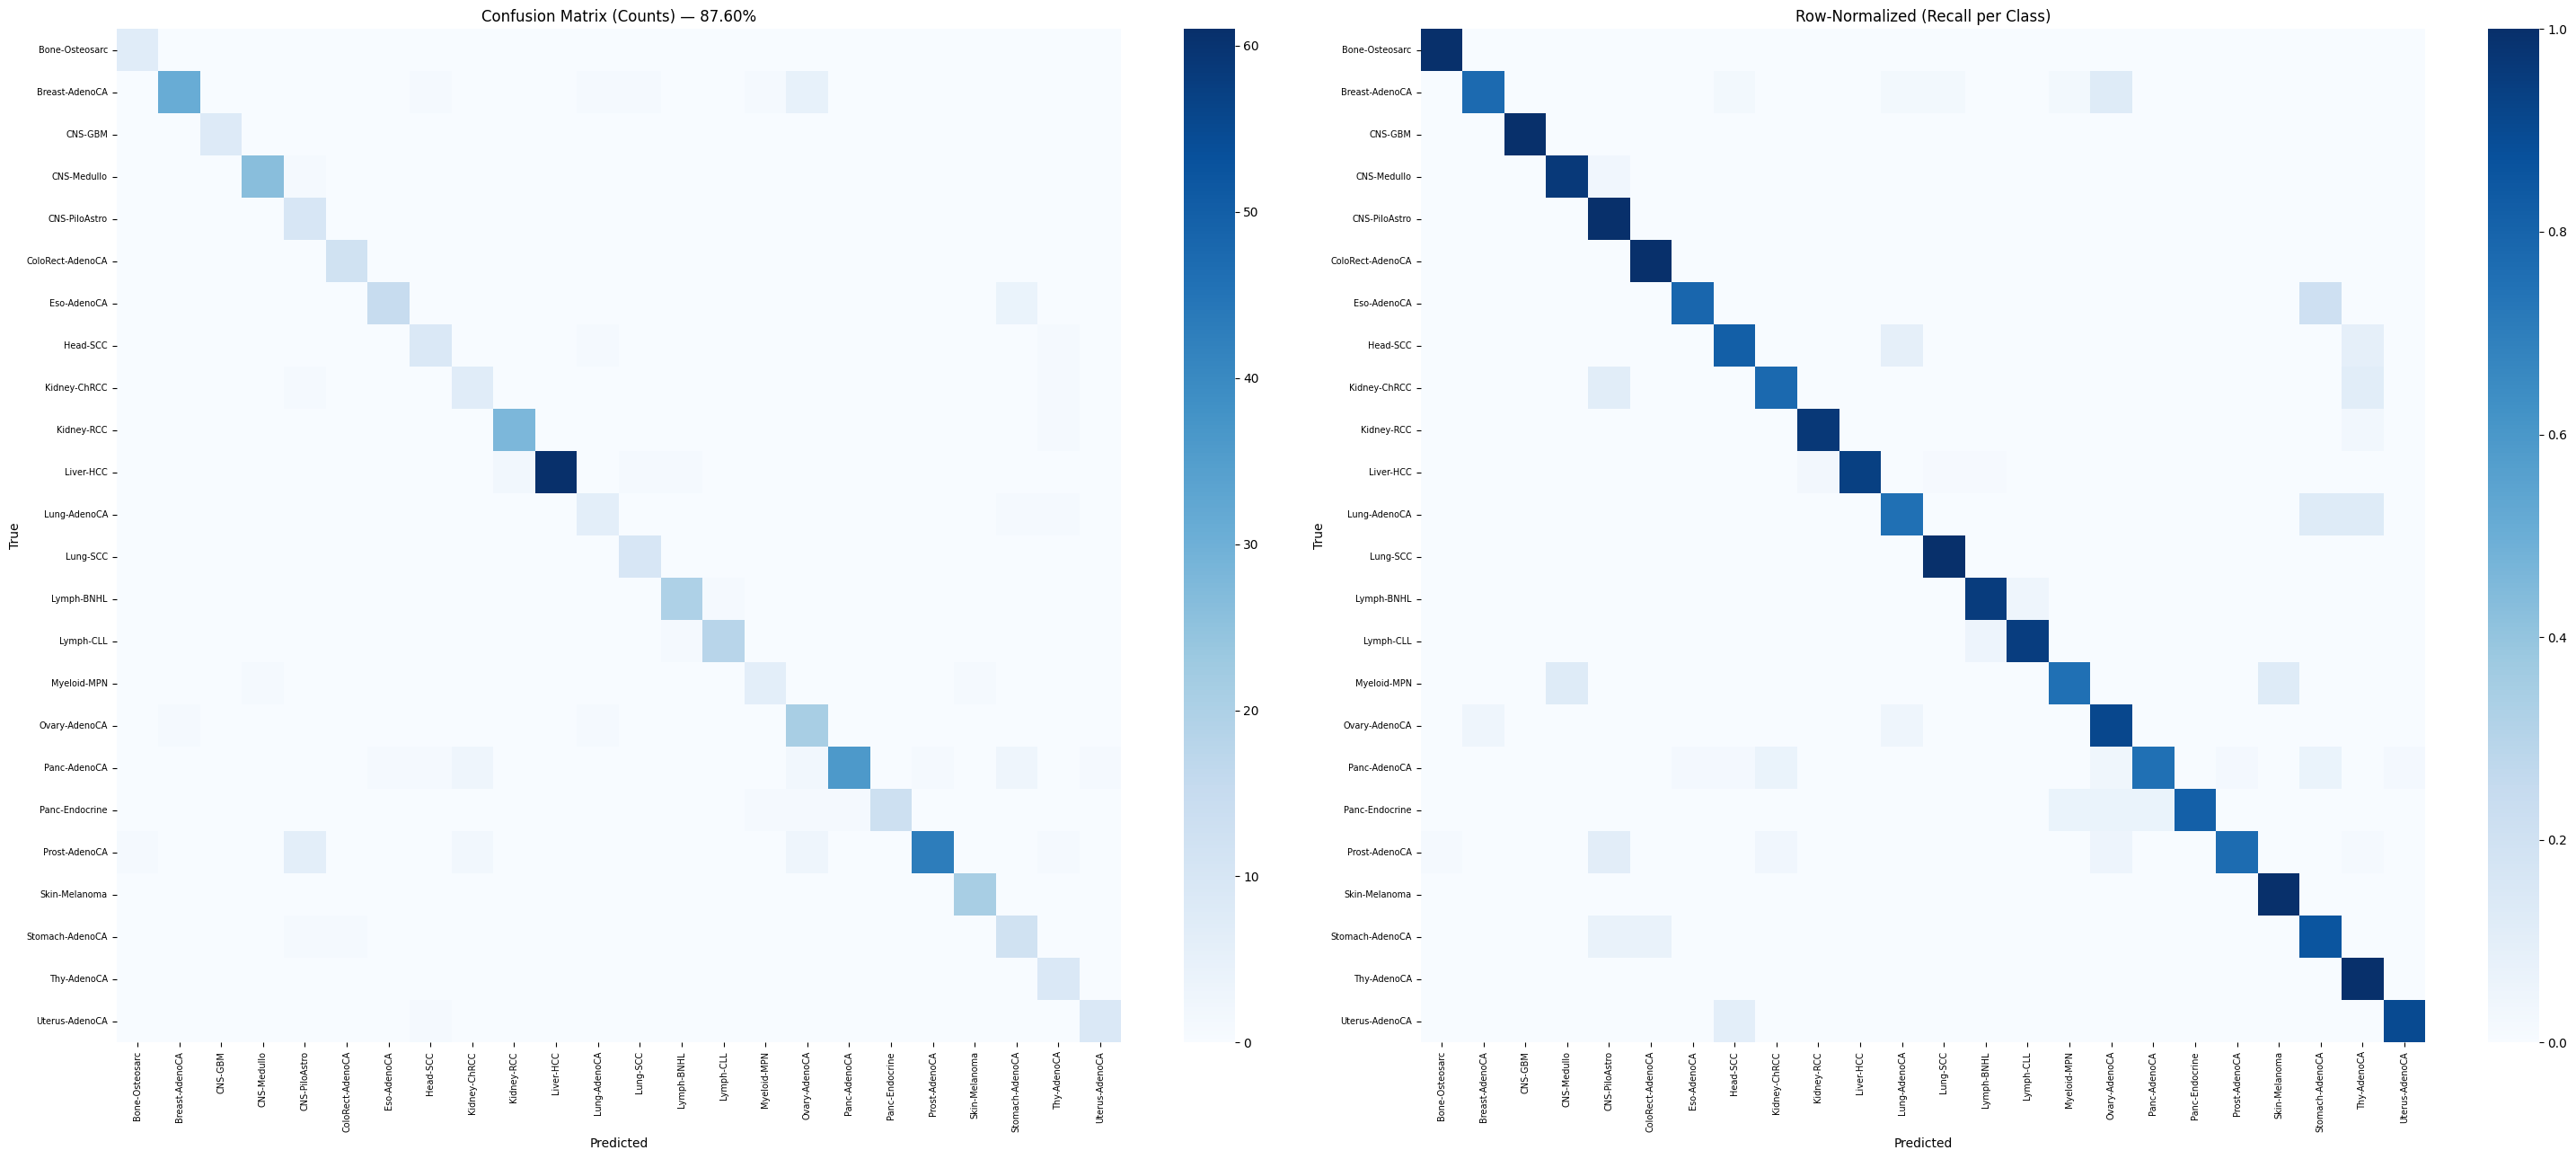

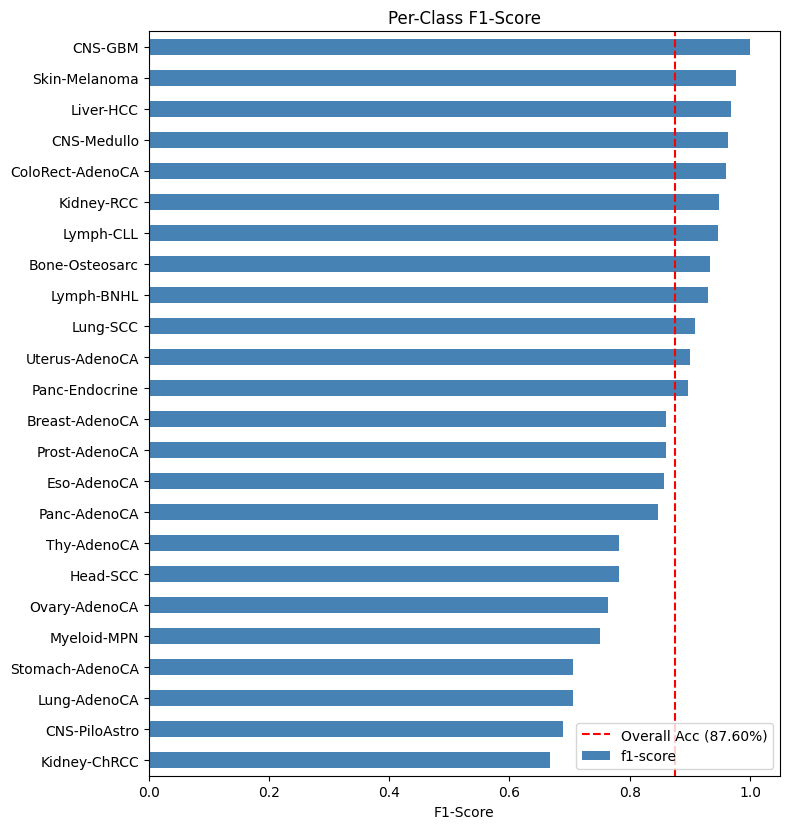


── 5 hardest cancer types ──
                 precision    recall  f1-score  support
Kidney-ChRCC      0.583333  0.777778  0.666667        9
CNS-PiloAstro     0.526316  1.000000  0.689655       10
Lung-AdenoCA      0.666667  0.750000  0.705882        8
Stomach-AdenoCA   0.600000  0.857143  0.705882       14
Myeloid-MPN       0.750000  0.750000  0.750000        8

── 5 easiest cancer types ──
                  precision    recall  f1-score  support
ColoRect-AdenoCA   0.923077  1.000000  0.960000       12
CNS-Medullo        0.962963  0.962963  0.962963       27
Liver-HCC          1.000000  0.938462  0.968254       65
Skin-Melanoma      0.954545  1.000000  0.976744       21
CNS-GBM            1.000000  1.000000  1.000000        8


In [15]:
def select_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    elif torch.backends.mps.is_available():
        return torch.device("mps")
    else:
        return torch.device("cpu")


# -------------------------------
# 0. DEVICE
# -------------------------------
def select_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    elif torch.backends.mps.is_available():
        return torch.device("mps")
    else:
        return torch.device("cpu")
device = select_device()
print(f"Device: {device}")

# -------------------------------
# 1. DATA PREP (FROM PREVIOUS PIPELINE)
# -------------------------------
X = X_train_f.copy()
y = y_train_f.copy()

# Standard scaling
#scaler = StandardScaler()
#X_scaled = scaler.fit_transform(X)


# Label encoding (fit ONLY on training set)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Encode test labels using same encoder
y_test_encoded = le.transform(y_test_f)

num_classes = len(le.classes_)
input_dim = X.shape[1]  # NOT scaled yet

# ==========================================
# 2. MIXUP DATA AUGMENTATION
# ==========================================
def mixup_batch(X, y, alpha=0.3):
    """Returns a mixed batch — interpolates between two random samples."""
    lam   = np.random.beta(alpha, alpha)
    idx   = torch.randperm(X.size(0))
    X_mix = lam * X + (1 - lam) * X[idx]
    y_a, y_b = y, y[idx]
    return X_mix, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

# ==========================================
# 3. ARCHITECTURE  (lighter + more dropout)
# ==========================================
class ResBlock(nn.Module):
    def __init__(self, dim, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, dim), nn.BatchNorm1d(dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(dim, dim), nn.BatchNorm1d(dim),
        )
        self.act = nn.GELU()
    def forward(self, x):
        return self.act(x + self.net(x))

class CancerNet(nn.Module):
    def __init__(self, input_size, num_classes, hidden=256, dropout=0.4):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Linear(input_size, hidden), nn.BatchNorm1d(hidden), nn.GELU(), nn.Dropout(dropout)
        )
        self.blocks = nn.Sequential(
            ResBlock(hidden, dropout=0.3),
            ResBlock(hidden, dropout=0.3),
            ResBlock(hidden, dropout=0.3),
        )
        self.head = nn.Sequential(
            nn.Linear(hidden, 128), nn.BatchNorm1d(128), nn.GELU(), nn.Dropout(0.2),
            nn.Linear(128, num_classes)
        )
    def forward(self, x):
        return self.head(self.blocks(self.stem(x)))

# ==========================================
# 4. TRAIN ONE FOLD  (reusable function)
# ==========================================
def train_fold(X_tr, y_tr, X_vl, y_vl, epochs=500, patience=50, lr=5e-4):
    device = select_device()

    # Weighted sampler so every class appears equally in each mini-batch
    class_counts = np.bincount(y_tr)
    sample_weights = 1.0 / class_counts[y_tr]
    sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

    def loader(X, y, sampler=None, bs=64):
        ds = TensorDataset(torch.FloatTensor(X), torch.LongTensor(y))
        return DataLoader(ds, batch_size=bs, sampler=sampler,
                          shuffle=(sampler is None))

    tr_loader = loader(X_tr, y_tr, sampler=sampler)
    vl_loader = loader(X_vl, y_vl, bs=128)

    # Class weights for loss (belt + suspenders approach)
    cw = compute_class_weight('balanced', classes=np.arange(num_classes), y=y_tr)
    cw_t = torch.FloatTensor(cw).to(device)

    net       = CancerNet(input_dim, num_classes).to(device)
    criterion = nn.CrossEntropyLoss(weight=cw_t, label_smoothing=0.05)
    opt       = optim.AdamW(net.parameters(), lr=lr, weight_decay=5e-4)
    sched     = optim.lr_scheduler.CosineAnnealingWarmRestarts(opt, T_0=50, T_mult=2)

    best_loss, best_w, patience_ctr = float('inf'), None, 0
    history = {'tl': [], 'vl': [], 'ta': [], 'va': []}

    for ep in range(epochs):
        # --- Train ---
        net.train()
        tl, tc, tt = 0, 0, 0
        for Xb, yb in tr_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            Xm, ya, yb2, lam = mixup_batch(Xb, yb, alpha=0.3)
            opt.zero_grad()
            out  = net(Xm)
            loss = mixup_criterion(criterion, out, ya, yb2, lam)
            loss.backward()
            nn.utils.clip_grad_norm_(net.parameters(), 1.0)
            opt.step()
            tl += loss.item() * Xb.size(0)
            # Accuracy on un-mixed batch for monitoring
            with torch.no_grad():
                tc += (net(Xb).argmax(1) == yb).sum().item()
            tt += Xb.size(0)
        sched.step()

        # --- Validate ---
        net.eval()
        vl, vc, vt = 0, 0, 0
        with torch.no_grad():
            for Xb, yb in vl_loader:
                Xb, yb = Xb.to(device), yb.to(device)
                out  = net(Xb)
                loss = criterion(out, yb)
                vl += loss.item() * Xb.size(0)
                vc += (out.argmax(1) == yb).sum().item()
                vt += Xb.size(0)

        tl /= tt; vl /= vt
        history['tl'].append(tl); history['vl'].append(vl)
        history['ta'].append(tc/tt); history['va'].append(vc/vt)

        if vl < best_loss:
            best_loss, best_w, patience_ctr = vl, copy.deepcopy(net.state_dict()), 0
        else:
            patience_ctr += 1
        if patience_ctr >= patience:
            break

    net.load_state_dict(best_w)
    return net, history

# ==========================================
# 5. 5-FOLD CROSS-VALIDATION  (robust eval)
# ==========================================
N_FOLDS  = 5
skf      = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
fold_nets = []
fold_accs = []

print("=" * 55)
print("  5-Fold Cross-Validation on Dev Set")
print("=" * 55)

all_histories = []
for fold, (tr_idx, vl_idx) in enumerate(skf.split(X, y_encoded)):

    # --- Split RAW data ---
    X_tr_raw = X.iloc[tr_idx]
    X_vl_raw = X.iloc[vl_idx]
    y_tr = y_encoded[tr_idx]
    y_vl = y_encoded[vl_idx]

    # --- Fit scaler ONLY on training fold ---
    scaler_fold = StandardScaler()
    X_tr = scaler_fold.fit_transform(X_tr_raw)
    X_vl = scaler_fold.transform(X_vl_raw)

    # --- Train ---
    net, hist = train_fold(X_tr, y_tr, X_vl, y_vl,
                           epochs=500, patience=50)

    fold_nets.append((net, scaler_fold))  # store scaler too
    all_histories.append(hist)

    # --- Evaluate fold ---
    net.eval()
    with torch.no_grad():
        out = net(torch.FloatTensor(X_vl).to(device))
        preds = out.argmax(1).cpu().numpy()

    acc = accuracy_score(y_vl, preds)
    fold_accs.append(acc)

    print(f"  Fold {fold+1}: Val Accuracy = {acc:.4f}")

print(f"\n  CV Mean ± Std: {np.mean(fold_accs):.4f} ± {np.std(fold_accs):.4f}\n")

# ==========================================
# 6. ENSEMBLE PREDICTION ON TEST SET
#    (average softmax probabilities across folds)
# ==========================================
device = select_device()
#X_test_nn_scaled = scaler.transform(X_test_f)
#X_test_t = torch.FloatTensor(X_test_nn_scaled).to(device)

probs_list = []
for net, scaler_fold in fold_nets:

    # Scale test set using that fold's scaler
    X_test_scaled = scaler_fold.transform(X_test_f)

    X_test_t = torch.FloatTensor(X_test_scaled).to(device)

    net.eval()
    with torch.no_grad():
        logits = net(X_test_t)
        probs = torch.softmax(logits, dim=1).cpu().numpy()

    probs_list.append(probs)

# Average probabilities
ensemble_probs = np.mean(probs_list, axis=0)
ensemble_preds = ensemble_probs.argmax(axis=1)

test_acc = accuracy_score(y_test_encoded, ensemble_preds)

print(f"Ensemble Test Accuracy: {test_acc:.4f} ({test_acc:.2%})")
print("=" * 55)
# ==========================================
# 7. VISUALIZATIONS
# ==========================================

# 7A. Training curves — best fold (highest val acc)
best_fold_idx = int(np.argmax(fold_accs))
hist = all_histories[best_fold_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(hist['tl'], label='Train'); axes[0].plot(hist['vl'], label='Val')
axes[0].set_title(f'Loss — Fold {best_fold_idx+1} (best)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(hist['ta'], label='Train'); axes[1].plot(hist['va'], label='Val')
axes[1].set_title(f'Accuracy — Fold {best_fold_idx+1} (best)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].legend(); axes[1].grid(True)
plt.suptitle('Training History (Best Fold)', fontsize=13)
plt.tight_layout(); plt.show()

# 7B. CV fold accuracy bar chart
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar([f'Fold {i+1}' for i in range(N_FOLDS)], fold_accs, color='steelblue', edgecolor='white')
ax.axhline(np.mean(fold_accs), color='red', linestyle='--', label=f'Mean {np.mean(fold_accs):.3f}')
ax.set_ylim(0.75, 1.0); ax.set_ylabel('Validation Accuracy')
ax.set_title('5-Fold Cross-Validation Accuracy'); ax.legend()
for b, v in zip(bars, fold_accs):
    ax.text(b.get_x() + b.get_width()/2, v + 0.003, f'{v:.3f}', ha='center', fontsize=9)
plt.tight_layout(); plt.show()

# 7C. Confusion matrices (counts + row-normalised)
dec_preds   = le.inverse_transform(ensemble_preds)
dec_targets = y_test_f.values 
unique_labels = le.classes_

cm      = confusion_matrix(dec_targets, dec_preds, labels=unique_labels)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(30, 13))
sns.heatmap(cm, ax=axes[0], annot=False, cmap='Blues',
            xticklabels=unique_labels, yticklabels=unique_labels)
axes[0].set_title(f'Confusion Matrix (Counts) — {test_acc:.2%}')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
axes[0].tick_params(axis='x', rotation=90, labelsize=7)
axes[0].tick_params(axis='y', labelsize=7)

sns.heatmap(cm_norm, ax=axes[1], annot=False, cmap='Blues',
            xticklabels=unique_labels, yticklabels=unique_labels, vmin=0, vmax=1)
axes[1].set_title('Row-Normalized (Recall per Class)')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
axes[1].tick_params(axis='x', rotation=90, labelsize=7)
axes[1].tick_params(axis='y', labelsize=7)
plt.tight_layout(); plt.show()

# 7D. Per-class F1 bar chart
report    = classification_report(dec_targets, dec_preds, labels=unique_labels, output_dict=True)
report_df = (
    pd.DataFrame(report).T
    .loc[unique_labels, ['precision', 'recall', 'f1-score', 'support']]
    .sort_values('f1-score', ascending=True)
)
report_df['support'] = report_df['support'].astype(int)

fig, ax = plt.subplots(figsize=(8, max(6, len(unique_labels) * 0.35)))
report_df['f1-score'].plot(kind='barh', ax=ax, color='steelblue')
ax.axvline(test_acc, color='red', linestyle='--', label=f'Overall Acc ({test_acc:.2%})')
ax.set_xlabel('F1-Score'); ax.set_title('Per-Class F1-Score'); ax.legend()
plt.tight_layout(); plt.show()

print("\n── 5 hardest cancer types ──")
print(report_df.head(5)[['precision','recall','f1-score','support']].to_string())
print("\n── 5 easiest cancer types ──")
print(report_df.tail(5)[['precision','recall','f1-score','support']].to_string())